#Mastering the Geometry of SVM Kernels


##Github -- https://github.com/swethasreebairi-tech/Machine-learning.git

--- Starting Grid Search Optimization ---
Optimal Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Validation Accuracy: 1.00



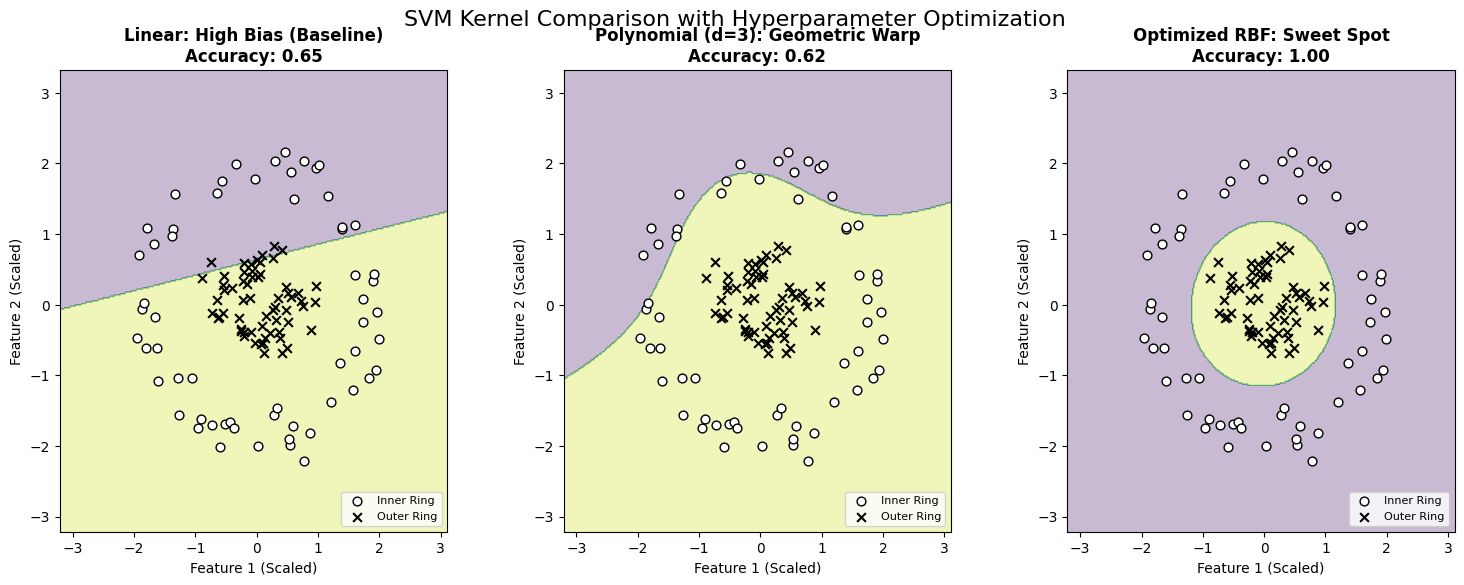


--- Model Comparison ---
Linear Kernel
Accuracy: 0.6500
              precision    recall  f1-score   support

           0       0.84      0.36      0.50        59
           1       0.60      0.93      0.73        61

    accuracy                           0.65       120
   macro avg       0.72      0.65      0.62       120
weighted avg       0.72      0.65      0.62       120

--------------------------------------------------
Polynomial Kernel (d=3)
Accuracy: 0.6250
              precision    recall  f1-score   support

           0       1.00      0.24      0.38        59
           1       0.58      1.00      0.73        61

    accuracy                           0.62       120
   macro avg       0.79      0.62      0.56       120
weighted avg       0.78      0.62      0.56       120

--------------------------------------------------
Optimized RBF Kernel
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59

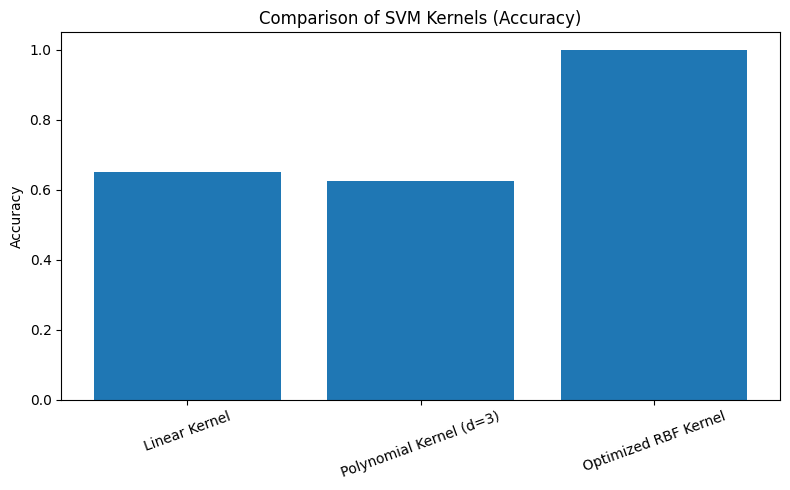

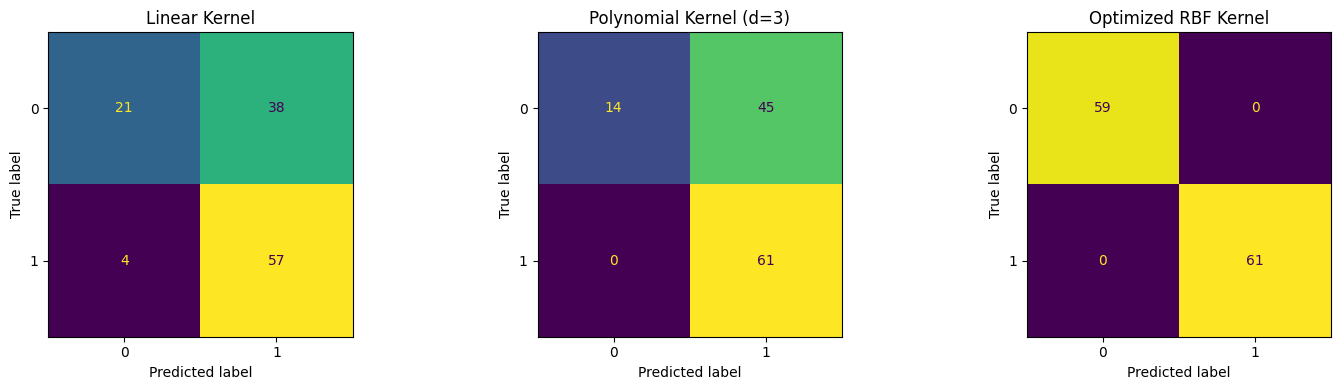


--- Final Classification Report (Optimized RBF) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00        61

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# =================================================================
# 1. DATASET SELECTION
# =================================================================
X, y = datasets.make_circles(n_samples=600, factor=0.3, noise=0.1, random_state=42)

# Scaling (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =================================================================
# 2. HYPERPARAMETER OPTIMIZATION (GridSearch)
# =================================================================
print("--- Starting Grid Search Optimization ---")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(svm.SVC(), param_grid, refit=True, cv=5)
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_

print(f"Optimal Parameters: {grid.best_params_}")
print(f"Validation Accuracy: {grid.best_score_:.2f}\n")

# =================================================================
# 3. MODEL COMPARISON SETUP
# =================================================================
models = [
    svm.SVC(kernel='linear', C=1.0).fit(X_train, y_train),
    svm.SVC(kernel='poly', degree=3, C=1.0).fit(X_train, y_train),
    best_rbf
]

titles = [
    'Linear: High Bias (Baseline)',
    'Polynomial (d=3): Geometric Warp',
    'Optimized RBF: Sweet Spot'
]

# =================================================================
# 4. DECISION BOUNDARY VISUALIZATION
# =================================================================
fig, sub = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)

h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

for clf, title, ax in zip(models, titles, sub.flatten()):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.3)

    # Accessible plotting
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
               c='white', edgecolors='k', marker='o', s=40, label='Inner Ring')

    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
               c='black', marker='x', s=40, label='Outer Ring')

    acc = accuracy_score(y_test, clf.predict(X_test))

    ax.set_title(f"{title}\nAccuracy: {acc:.2f}", fontweight='bold')
    ax.set_xlabel("Feature 1 (Scaled)")
    ax.set_ylabel("Feature 2 (Scaled)")
    ax.legend(loc='lower right', prop={'size': 8})

plt.suptitle("SVM Kernel Comparison with Hyperparameter Optimization", fontsize=16)
plt.show()

# =================================================================
# 5. MODEL COMPARISON (NEW SECTION)
# =================================================================
print("\n--- Model Comparison ---")

model_names = [
    "Linear Kernel",
    "Polynomial Kernel (d=3)",
    "Optimized RBF Kernel"
]

accuracies = []

for name, model in zip(model_names, models):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# =================================================================
# 6. ACCURACY BAR CHART
# =================================================================
plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.title("Comparison of SVM Kernels (Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =================================================================
# 7. CONFUSION MATRICES
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model, name in zip(axes, models, model_names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# =================================================================
# FINAL REPORT FOR BEST MODEL
# =================================================================
print("\n--- Final Classification Report (Optimized RBF) ---")
print(classification_report(y_test, best_rbf.predict(X_test)))